# Dataset Exploration and Bias Analysis

This notebook investigates the Fake and Real News Dataset prior to model development.

Objectives:

1. Assess dataset quality.
2. Analyze class distribution.
3. Identify duplicates.
4. Investigate metadata bias.
5. Determine whether label leakage exists.

In [1]:
!pip install kaggle

In [2]:
from getpass import getpass
import os

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter Kaggle Token: ")

Enter Kaggle Token: ··········


In [3]:
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset

Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
fake-and-real-news-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
#Extract Dataset
import zipfile

with zipfile.ZipFile("fake-and-real-news-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

#Check Files
import os

os.listdir("data")

['Fake.csv', 'True.csv']

In [5]:
#Load the Dataset
import pandas as pd

fake = pd.read_csv("data/Fake.csv")
real = pd.read_csv("data/True.csv")

print("Fake:", fake.shape)
print("Real:", real.shape)

Fake: (23481, 4)
Real: (21417, 4)


In [6]:
#Add the Labels
fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real], ignore_index=True)

## Dataset Overview

The fake and real news datasets are merged into a single dataframe.

Features:
- title
- text
- subject
- date
- label

Labels:
- 0 = Fake
- 1 = Real

In [7]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


## Class Distribution

A balanced dataset is important for reliable model evaluation.

This section examines the distribution of fake and real articles.

In [10]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


In [11]:
df["subject"].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


## Duplicate Analysis

Duplicate records may artificially inflate performance and introduce information leakage.

Therefore, duplicates are identified and removed before experimentation.

In [12]:
print(df.duplicated().sum())

209


In [13]:
df = df.drop_duplicates()

## Subject–Label Relationship

This section investigates whether the subject field is associated with class labels.

A strong association may indicate dataset bias.

In [14]:
pd.crosstab(df["subject"], df["label"])

label,0,1
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4459,0
politics,6838,0
politicsNews,0,11220
worldnews,0,9991


## Article Length Analysis

Article length is examined to determine whether simple structural characteristics differ between fake and real news articles.

In [15]:
df["article_length"] = df["text"].apply(len)

df.groupby("label")["article_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,23478.0,2547.555882,2532.998914,1.0,1433.0,2166.0,3032.0,51794.0
1,21211.0,2378.042337,1684.467512,1.0,903.5,2216.0,3226.5,29781.0


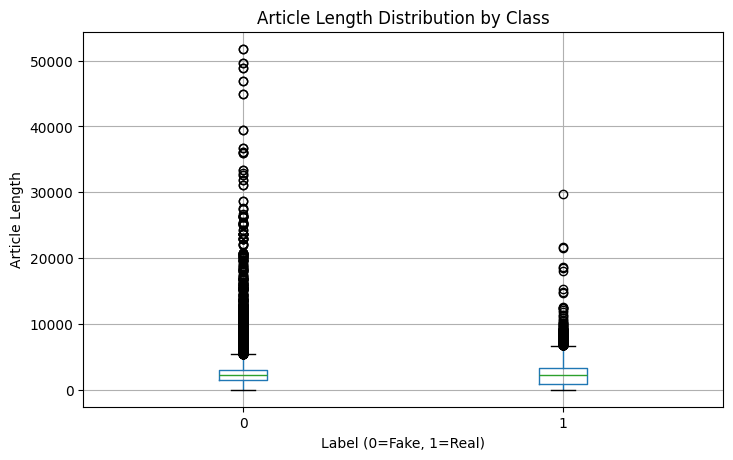

In [16]:
import matplotlib.pyplot as plt

df.boxplot(
    column="article_length",
    by="label",
    figsize=(8,5)
)

plt.suptitle("")
plt.title("Article Length Distribution by Class")
plt.xlabel("Label (0=Fake, 1=Real)")
plt.ylabel("Article Length")
plt.show()

## Subject Leakage Experiment

To test whether metadata alone can predict article labels, a Logistic Regression model is trained using only the subject feature.

No article text is provided to the model.

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_subject = le.fit_transform(df["subject"]).reshape(-1,1)

y = df["label"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_subject,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [20]:
pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



# Conclusions

Key findings:

- Dataset contains 44,898 articles.
- Dataset is approximately balanced.
- 209 duplicate records were removed.
- Subject categories are perfectly aligned with class labels.
- A subject-only classifier achieves 100% accuracy.
- Significant label leakage exists.

Implication:

Future experiments will exclude metadata features and rely solely on article title and text.